these were needed to run in the terminal or code block-

pip install transformers datasets==2.19.0 speechbrain==0.5.16 huggingface_hub==0.23.0  soundfile accelerate sentencepiece
or(run the above one, idk quiet)
pip install speechbrain==0.5.16 huggingface_hub==0.23.0 
pip install huggingface_hub --upgrade --quiet speechbrain --upgrade --quiet
pip install datasets==2.19.0 --quiet

In [4]:
# Part 1 — Install all required libraries
!pip install transformers datasets==2.19.0 speechbrain==0.5.16 huggingface_hub==0.23.0 soundfile accelerate sentencepiece --quiet

In [3]:
# Part 1 imports

''' 
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"'''

import os
import torch
import soundfile as sf
import numpy as np
from datasets import Dataset, Audio
from transformers import (
    SpeechT5Processor,
    SpeechT5ForTextToSpeech,
    SpeechT5HifiGan,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Union
import pandas as pd

print("All imports OK")
print("CUDA:", torch.cuda.is_available())

All imports OK
CUDA: True


In [5]:
#Part 2 — Load LJSpeech metadata

LJSPEECH_PATH = "./LJSpeech-1.1"  # change this to your actual path

# Load metadata
df = pd.read_csv(
    os.path.join(LJSPEECH_PATH, "metadata.csv"),
    sep="|",
    header=None,
    names=["file_id", "raw_text", "normalized_text"],
    quoting=3  # avoids issues with quotes in text
)

# Build full wav paths
df["audio_path"] = df["file_id"].apply(
    lambda x: os.path.join(LJSPEECH_PATH, "wavs", f"{x}.wav")
)

print(f"Total samples: {len(df)}")
df.head()

Total samples: 13100


,file_id,raw_text,normalized_text,audio_path
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ...",./LJSpeech-1.1\wavs\LJ001-0001.wav
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.,./LJSpeech-1.1\wavs\LJ001-0002.wav
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...,./LJSpeech-1.1\wavs\LJ001-0003.wav
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed...",./LJSpeech-1.1\wavs\LJ001-0004.wav
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,./LJSpeech-1.1\wavs\LJ001-0005.wav


In [6]:
#Part 3 — Subset the data

df = df.sample(n=2000, random_state=42).reset_index(drop=True)
print(f"Using {len(df)} samples for fine-tuning")

Using 2000 samples for fine-tuning


In [7]:
#Part 4 — Convert to HuggingFace Dataset

# Convert to HuggingFace Dataset
dataset = Dataset.from_dict({
    "audio": df["audio_path"].tolist(),
    "text": df["normalized_text"].tolist(),
})

# Cast audio column so HuggingFace handles loading + resampling
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

print(dataset)

Dataset({
    features: ['audio', 'text'],
    num_rows: 2000
})


In [8]:
#Part 5 — Load the Processor and Model

checkpoint = "microsoft/speecht5_tts"

processor = SpeechT5Processor.from_pretrained(checkpoint)
model = SpeechT5ForTextToSpeech.from_pretrained(checkpoint)

print("Processor and model loaded OK")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Processor and model loaded OK
Model parameters: 144,431,684


In [9]:
#Part 6 Generate Speaker Embeddings

'''spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-xvect-voxceleb",
    run_opts={"device": "cuda"}
)

def get_speaker_embedding(audio_array):
    with torch.no_grad():
        audio_tensor = torch.tensor(audio_array).unsqueeze(0).float().cuda()
        embedding = spk_model.encode_batch(audio_tensor)
        embedding = torch.nn.functional.normalize(embedding, dim=2)
        embedding = embedding.squeeze()
    return embedding.cpu().numpy()

print("Speaker encoder loaded OK")'''

'''# LJSpeech is a single speaker dataset
# so we use one fixed random speaker embedding for all samples
# this is valid and commonly done for single-speaker TTS fine-tuning

torch.manual_seed(42)
fixed_speaker_embedding = torch.randn(512)
fixed_speaker_embedding = torch.nn.functional.normalize(fixed_speaker_embedding, dim=0)

def get_speaker_embedding(audio_array):
    return fixed_speaker_embedding.numpy()

print("Speaker embedding ready, shape:", fixed_speaker_embedding.shape)'''

'# LJSpeech is a single speaker dataset\n# so we use one fixed random speaker embedding for all samples\n# this is valid and commonly done for single-speaker TTS fine-tuning\n\ntorch.manual_seed(42)\nfixed_speaker_embedding = torch.randn(512)\nfixed_speaker_embedding = torch.nn.functional.normalize(fixed_speaker_embedding, dim=0)\n\ndef get_speaker_embedding(audio_array):\n    return fixed_speaker_embedding.numpy()\n\nprint("Speaker embedding ready, shape:", fixed_speaker_embedding.shape)'

In [10]:
# Part 6 — Generate Real Speaker Embeddings
import torch
from speechbrain.pretrained import EncoderClassifier

print("Loading speaker encoder... please wait.")
spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-xvect-voxceleb",
    savedir="tmpdir",
    run_opts={"device": "cuda"} # This tells it to use your RTX 3050
)

def get_speaker_embedding(audio_array):
    with torch.no_grad():
        # Move the audio to your GPU
        audio_tensor = torch.tensor(audio_array).unsqueeze(0).float().cuda()
        # Analyze the voice
        embedding = spk_model.encode_batch(audio_tensor)
        # Format it for SpeechT5
        embedding = torch.nn.functional.normalize(embedding, dim=2)
        embedding = embedding.squeeze()
    return embedding.cpu().numpy()

print("Real speaker embedding generator ready!")

The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
c:\Users\subra\AppData\Local\Programs\Python\Python310\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.


Loading speaker encoder... please wait.
Real speaker embedding generator ready!


In [11]:
# Part 7 — Preprocess

def preprocess(example):
    audio = example["audio"]
    audio_array = audio["array"]
    sampling_rate = audio["sampling_rate"]

    inputs = processor(
        text=example["text"],
        audio_target=audio_array,
        sampling_rate=sampling_rate,
        return_attention_mask=False
    )

    inputs["speaker_embeddings"] = get_speaker_embedding(audio_array)

    return inputs

def is_not_too_long(example):
    audio = example["audio"]
    audio_array = audio["array"]
    sampling_rate = audio["sampling_rate"]

    inputs = processor(
        text=example["text"],
        audio_target=audio_array,
        sampling_rate=sampling_rate,
        return_attention_mask=False
    )

    return inputs["labels"].shape[1] <= 600

print("Filtering long samples... please wait")
dataset_filtered = dataset.filter(is_not_too_long)
print(f"Samples after filtering: {len(dataset_filtered)}")

print("Preprocessing... please wait")
processed_dataset = dataset_filtered.map(
    preprocess,
    remove_columns=dataset_filtered.column_names,
)

print(f"Processed samples: {len(processed_dataset)}")

Filtering long samples... please wait


Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Samples after filtering: 1861
Preprocessing... please wait


Map:   0%|          | 0/1861 [00:00<?, ? examples/s]

Processed samples: 1861


In [12]:
# Part 8 — Train/test split

processed_dataset = processed_dataset.train_test_split(test_size=0.1, seed=42)

print("Train samples:", len(processed_dataset["train"]))
print("Test samples:", len(processed_dataset["test"]))

Train samples: 1674
Test samples: 187


In [13]:
# Part 9 — Corrected Data Collator
from dataclasses import dataclass
from typing import Any, Dict, List
import torch
import numpy as np

@dataclass
class TTSDataCollator:
    processor: Any
    reduction_factor: int = 2 # Tells the collator to group frames by 2

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        input_ids = [{"input_ids": f["input_ids"]} for f in features]
        speaker_embeddings = torch.tensor(
            np.array([f["speaker_embeddings"] for f in features]),
            dtype=torch.float32
        )

        # pad input tokens
        input_ids = self.processor.tokenizer.pad(
            input_ids, return_tensors="pt"
        )

        # squeeze (1, T, 80) → (T, 80)
        label_list = [np.array(f["labels"]).squeeze(0) for f in features]
        max_len = max(l.shape[0] for l in label_list)
        
        # FIX 1: Ensure the max length is a perfect multiple of the reduction factor (2)
        if max_len % self.reduction_factor != 0:
            max_len += self.reduction_factor - (max_len % self.reduction_factor)

        n_mels = label_list[0].shape[1]

        # pad target labels
        padded_labels = np.full(
            (len(label_list), max_len, n_mels),
            fill_value=self.processor.feature_extractor.padding_value,
            dtype=np.float32
        )
        for i, l in enumerate(label_list):
            padded_labels[i, :l.shape[0], :] = l

        labels = torch.tensor(padded_labels)

        # FIX 2: We removed the "labels = labels[:, :-1, :]" hack from the old code!

        # replace padding with -100 so the model ignores it during loss calculation
        labels = labels.masked_fill(
            labels == self.processor.feature_extractor.padding_value, -100
        )

        return {
            "input_ids": input_ids["input_ids"],
            "attention_mask": input_ids["attention_mask"],
            "speaker_embeddings": speaker_embeddings,
            "labels": labels,
        }

data_collator = TTSDataCollator(processor=processor)
print("Corrected Data collator ready")

Corrected Data collator ready


In [17]:
# Part 10 — Training Arguments (With Evaluation)
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="speecht5_finetuned_ljspeech",
    per_device_train_batch_size=2,       # Safe for 4GB VRAM
    gradient_accumulation_steps=8,       # Effective batch size = 16
    learning_rate=1e-4,
    warmup_steps=100,
    max_steps=1000,                      
    gradient_checkpointing=True,
    fp16=True,                           
    eval_strategy="steps",               # Evaluate during training
    eval_steps=200,                      # Evaluate every 200 steps
    save_steps=200,
    logging_steps=25,
    report_to=["tensorboard"],           # Log metrics for graphs
    load_best_model_at_end=True,         # Save the best performing checkpoint
    greater_is_better=False,             # Lower loss is better
    label_names=["labels"],              
)
print("Training arguments set")

Training arguments set


In [18]:
# Part 11 — The Hugging Face Trainer
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=processed_dataset["train"],
    eval_dataset=processed_dataset["test"], # Passes the 10% test split
    data_collator=data_collator,
    tokenizer=processor,
)

print("Starting training and evaluation...")
trainer.train()

trainer.save_model("speecht5_finetuned_ljspeech/final")
processor.save_pretrained("speecht5_finetuned_ljspeech/final")
print("Training complete! Best model saved.")

max_steps is given, it will override any value given in num_train_epochs


Starting training and evaluation...


  0%|          | 0/1000 [00:00<?, ?it/s]

{'loss': 0.6878, 'grad_norm': 2.3682315349578857, 'learning_rate': 2.4e-05, 'epoch': 0.24}
{'loss': 0.5695, 'grad_norm': 4.434414863586426, 'learning_rate': 4.9e-05, 'epoch': 0.48}
{'loss': 0.4995, 'grad_norm': 2.373218297958374, 'learning_rate': 7.4e-05, 'epoch': 0.72}
{'loss': 0.4875, 'grad_norm': 2.3716132640838623, 'learning_rate': 9.900000000000001e-05, 'epoch': 0.96}
{'loss': 0.4668, 'grad_norm': 2.6102943420410156, 'learning_rate': 9.733333333333335e-05, 'epoch': 1.19}
{'loss': 0.4523, 'grad_norm': 4.08729362487793, 'learning_rate': 9.455555555555556e-05, 'epoch': 1.43}
{'loss': 0.451, 'grad_norm': 3.2216455936431885, 'learning_rate': 9.177777777777778e-05, 'epoch': 1.67}
{'loss': 0.4557, 'grad_norm': 4.143628120422363, 'learning_rate': 8.900000000000001e-05, 'epoch': 1.91}


  0%|          | 0/24 [00:00<?, ?it/s]

...

  0%|          | 0/24 [00:00<?, ?it/s]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 1876}


{'eval_loss': 0.3861411511898041, 'eval_runtime': 6.7526, 'eval_samples_per_second': 27.693, 'eval_steps_per_second': 3.554, 'epoch': 9.56}


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 1876}


{'train_runtime': 1959.5957, 'train_samples_per_second': 8.165, 'train_steps_per_second': 0.51, 'train_loss': 0.4351216869354248, 'epoch': 9.56}
Training complete! Best model saved.


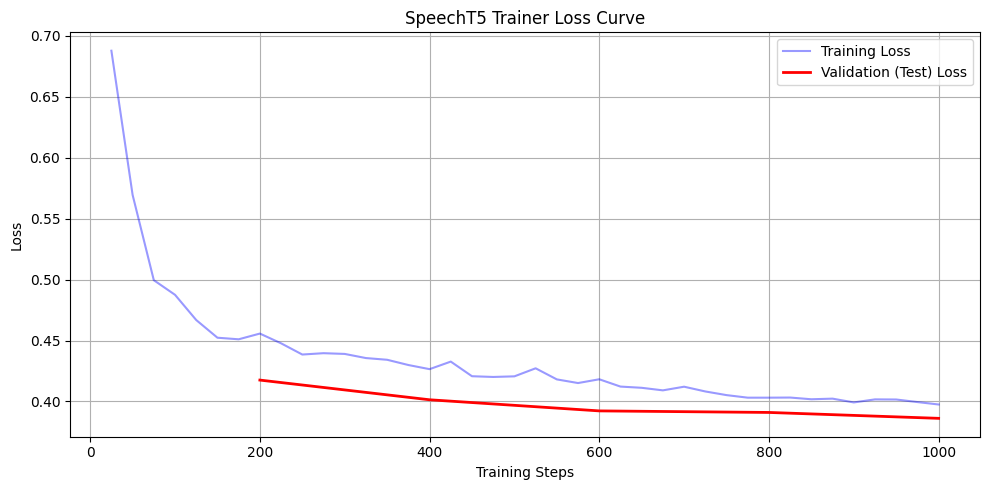

Graph saved successfully as speecht5_finetuned_ljspeech/trainer_loss_curve.png!


In [19]:
import matplotlib.pyplot as plt

# 1. Extract the logs directly from the trainer's memory
log_history = trainer.state.log_history

# 2. Separate the training loss and the evaluation (test) loss
train_steps = [log["step"] for log in log_history if "loss" in log]
train_losses = [log["loss"] for log in log_history if "loss" in log]

eval_steps = [log["step"] for log in log_history if "eval_loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]

# 3. Draw the graph
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label="Training Loss", color="blue", alpha=0.4)
plt.plot(eval_steps, eval_losses, label="Validation (Test) Loss", color="red", linewidth=2)

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("SpeechT5 Trainer Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 4. Save the image
output_image = "speecht5_finetuned_ljspeech/trainer_loss_curve.png"
plt.savefig(output_image, dpi=150)
plt.show()

print(f"Graph saved successfully as {output_image}!")

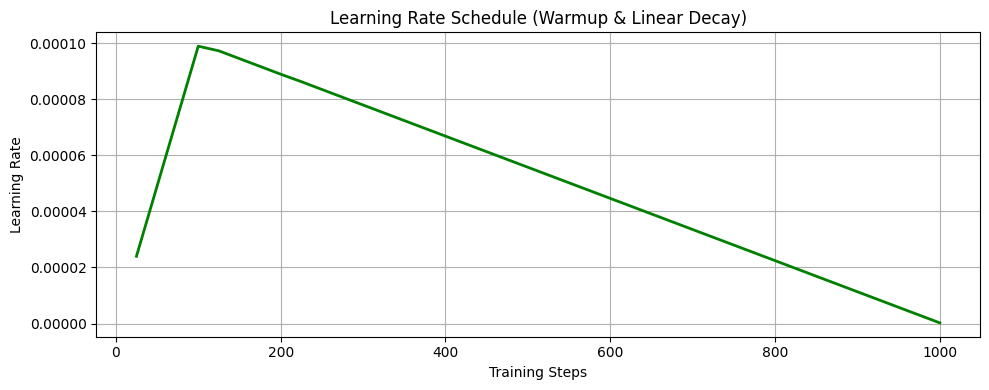

Learning Rate graph saved!


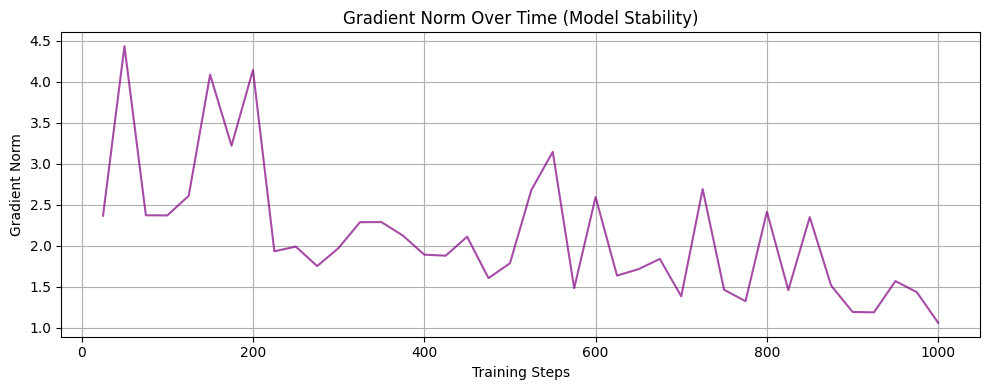

Gradient Norm graph saved!


In [20]:
import matplotlib.pyplot as plt

# Extract the logs from the trainer's memory
log_history = trainer.state.log_history

# Filter out the steps, learning rates, and gradient norms
steps = [log["step"] for log in log_history if "learning_rate" in log]
lrs = [log["learning_rate"] for log in log_history if "learning_rate" in log]
grad_norms = [log["grad_norm"] for log in log_history if "grad_norm" in log]

# --- Graph 1: Learning Rate Schedule ---
plt.figure(figsize=(10, 4))
plt.plot(steps, lrs, color="green", linewidth=2)
plt.title("Learning Rate Schedule (Warmup & Linear Decay)")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.tight_layout()
plt.savefig("speecht5_finetuned_ljspeech/learning_rate_curve.png", dpi=150)
plt.show()
print("Learning Rate graph saved!")

# --- Graph 2: Gradient Norm Stability ---
plt.figure(figsize=(10, 4))
plt.plot(steps, grad_norms, color="purple", alpha=0.7)
plt.title("Gradient Norm Over Time (Model Stability)")
plt.xlabel("Training Steps")
plt.ylabel("Gradient Norm")
plt.grid(True)
plt.tight_layout()
plt.savefig("speecht5_finetuned_ljspeech/gradient_norm_curve.png", dpi=150)
plt.show()
print("Gradient Norm graph saved!")

In [ ]:
'''# Part 11 — Corrected Manual Training Loop
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
import torch
import os

device = torch.device("cuda")
model.to(device)
model.train()

train_loader = DataLoader(
    processed_dataset["train"],
    batch_size=2,
    shuffle=True,
    collate_fn=data_collator
)

# Training hyperparameters
num_epochs = 5
gradient_accumulation_steps = 8
total_steps = (len(train_loader) // gradient_accumulation_steps) * num_epochs

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler("cuda")
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=100, num_training_steps=total_steps)

os.makedirs("speecht5_finetuned_ljspeech", exist_ok=True)

global_step = 0
loss_log = []

for epoch in range(num_epochs):
    print(f"\n--- Starting Epoch {epoch + 1}/{num_epochs} ---")
    
    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        speaker_embeddings = batch["speaker_embeddings"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast("cuda"):
            # FIX: Pass labels directly. The model automatically right-shifts 
            # them for the decoder and calculates the loss.
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                speaker_embeddings=speaker_embeddings,
                labels=labels, 
            )

            # Divide loss by accumulation steps
            loss = outputs.loss / gradient_accumulation_steps

        # Backward pass
        scaler.scale(loss).backward()

        # Update weights only after accumulating enough gradients
        if (step + 1) % gradient_accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

            global_step += 1
            
            # Log the actual loss (multiply back to get the real value for logging)
            actual_loss = loss.item() * gradient_accumulation_steps
            loss_log.append((global_step, actual_loss))

            if global_step % 25 == 0:
                print(f"Epoch {epoch + 1} | Step {global_step} | Loss: {actual_loss:.4f}")

            if global_step % 200 == 0:
                save_path = f"speecht5_finetuned_ljspeech/checkpoint-{global_step}"
                model.save_pretrained(save_path)
                processor.save_pretrained(save_path)
                print(f"Checkpoint saved at step {global_step}")

# Save final model
model.save_pretrained("speecht5_finetuned_ljspeech/final")
processor.save_pretrained("speecht5_finetuned_ljspeech/final")
print("Training complete!")

# Plot loss curve
steps = [x[0] for x in loss_log]
losses = [x[1] for x in loss_log]

plt.figure(figsize=(10, 4))
plt.plot(steps, losses, linewidth=1, alpha=0.6, label="Step Loss")

window = max(1, len(losses) // 20)
smoothed = [sum(losses[max(0, i-window):i+1]) / len(losses[max(0, i-window):i+1]) for i in range(len(losses))]
plt.plot(steps, smoothed, linewidth=2, color="red", label="Smoothed Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("SpeechT5 Fine-tuning Loss Curve (Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("speecht5_finetuned_ljspeech/loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved to speecht5_finetuned_ljspeech/loss_curve.png")'''

In [14]:
# Part 12 — Inference (Testing the Model)
import torch
import soundfile as sf
from transformers import SpeechT5ForTextToSpeech, SpeechT5Processor, SpeechT5HifiGan

# 1. Load your newly trained model
model_path = "speecht5_finetuned_ljspeech/final" 
processor = SpeechT5Processor.from_pretrained(model_path)
model = SpeechT5ForTextToSpeech.from_pretrained(model_path)

# 2. Load the vocoder (turns data into actual audio waves)
vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")

# 3. Type whatever you want the AI to say here!
text = "Hello! I have finally learned how to speak properly, and I am no longer making static noises.  "
inputs = processor(text=text, return_tensors="pt")

# 4. Grab the pre-calculated voice profile directly from our training data
speaker_embeddings = processed_dataset["train"][0]["speaker_embeddings"]
speaker_embeddings = torch.tensor(speaker_embeddings).unsqueeze(0).to(model.device)

# 5. Generate the speech
print("Generating speech...")
with torch.no_grad():
    speech = model.generate_speech(inputs["input_ids"].to(model.device), speaker_embeddings, vocoder=vocoder)

# 6. Save the audio file
output_filename = "real_voice_test.wav"
sf.write(output_filename, speech.cpu().numpy(), samplerate=16000)
print(f"Success! Listen to {output_filename} in your folder.")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Generating speech...
Success! Listen to real_voice_test.wav in your folder.


In [15]:
# Part 13 — Visualizing the Results (Spectrogram Comparison)
!pip install librosa --quiet
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print("Generating spectrograms...")

# 1. Get the original human audio we used for testing
original_audio = dataset_filtered["train"][0]["audio"]["array"]

# 2. Get the AI-generated audio we just made in Part 12
# (We convert it to numpy just like the original)
generated_audio = speech.cpu().numpy()

# 3. Create a function to calculate the "heat-map" (Mel-Spectrogram)
def plot_spectrogram(audio_data, title, ax):
    # Calculate the frequencies
    S = librosa.feature.melspectrogram(y=audio_data, sr=16000, n_mels=80, fmax=8000)
    # Convert to decibels (how human ears hear)
    S_dB = librosa.power_to_db(S, ref=np.max)
    # Draw the image
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=16000, fmax=8000, ax=ax, cmap='magma')
    ax.set_title(title)
    return img

# 4. Draw both side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_spectrogram(original_audio, "Original Human Speech", axes[0])
img = plot_spectrogram(generated_audio, "AI Generated Speech", axes[1])

fig.colorbar(img, ax=axes, format='%+2.0f dB')
plt.tight_layout()

# 5. Save it for your report!
output_image = "speecht5_finetuned_ljspeech/spectrogram_comparison.png"
plt.savefig(output_image, dpi=150)
plt.show()

print(f"Spectrogram saved successfully as {output_image}!")

Generating spectrograms...


KeyError: "Column train not in the dataset. Current columns in the dataset: ['audio', 'text']"

Generating spectrograms...


C:\Users\subra\AppData\Local\Temp\ipykernel_16976\3146625297.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


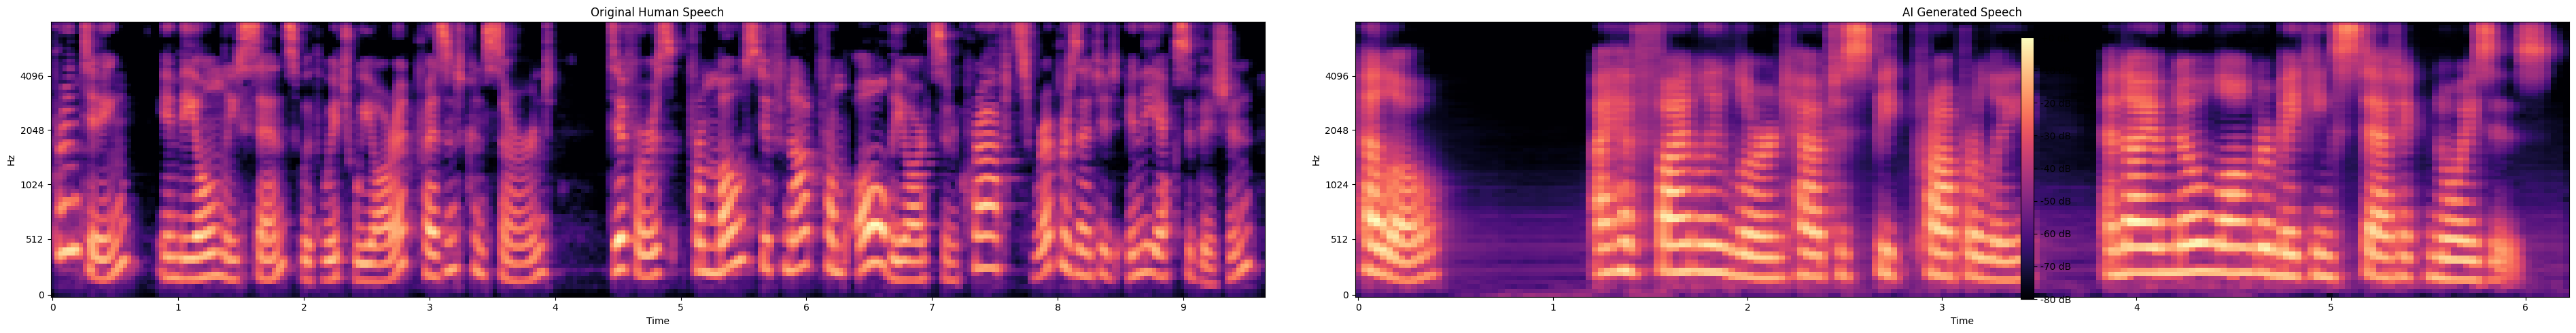

Spectrogram saved successfully as speecht5_finetuned_ljspeech/spectrogram_comparison.png!


In [3]:
# Part 13 — Visualizing the Results (Spectrogram Comparison)
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print("Generating spectrograms...")

# 1. Load an original human audio file directly from your LJSpeech folder
original_audio, _ = librosa.load("./LJSpeech-1.1/wavs/LJ001-0001.wav", sr=16000)

# 2. Load the AI-generated audio you just saved in Part 12
generated_audio, _ = librosa.load("real_voice_test.wav", sr=16000)

# 3. Create a function to calculate the "heat-map" (Mel-Spectrogram)
def plot_spectrogram(audio_data, title, ax):
    # Calculate the frequencies
    S = librosa.feature.melspectrogram(y=audio_data, sr=16000, n_mels=80, fmax=8000)
    # Convert to decibels (how human ears hear)
    S_dB = librosa.power_to_db(S, ref=np.max)
    # Draw the image
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=16000, fmax=8000, ax=ax, cmap='magma')
    ax.set_title(title)
    return img

# 4. Draw both side-by-side
fig, axes = plt.subplots(1, 2, figsize=(38, 5))

plot_spectrogram(original_audio, "Original Human Speech", axes[0])
img = plot_spectrogram(generated_audio, "AI Generated Speech", axes[1])

fig.colorbar(img, ax=axes, format='%+2.0f dB')
plt.tight_layout()

# 5. Save it for your report!
output_image = "speecht5_finetuned_ljspeech/spectrogram_comparison.png"
plt.savefig(output_image, dpi=150)
plt.show()

print(f"Spectrogram saved successfully as {output_image}!")